# GeoScope AI - Satellite Land Use Classification

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


In [2]:
DATASET_PATH = "dataset/EuroSAT_RGB"

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

print("\nClasses Found:")
print(class_names)

Found 26984 files belonging to 10 classes.
Using 21588 files for training.
Found 26984 files belonging to 10 classes.
Using 5396 files for validation.

Classes Found:
['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [4]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(300).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

print("Dataset optimized.")

Dataset optimized.


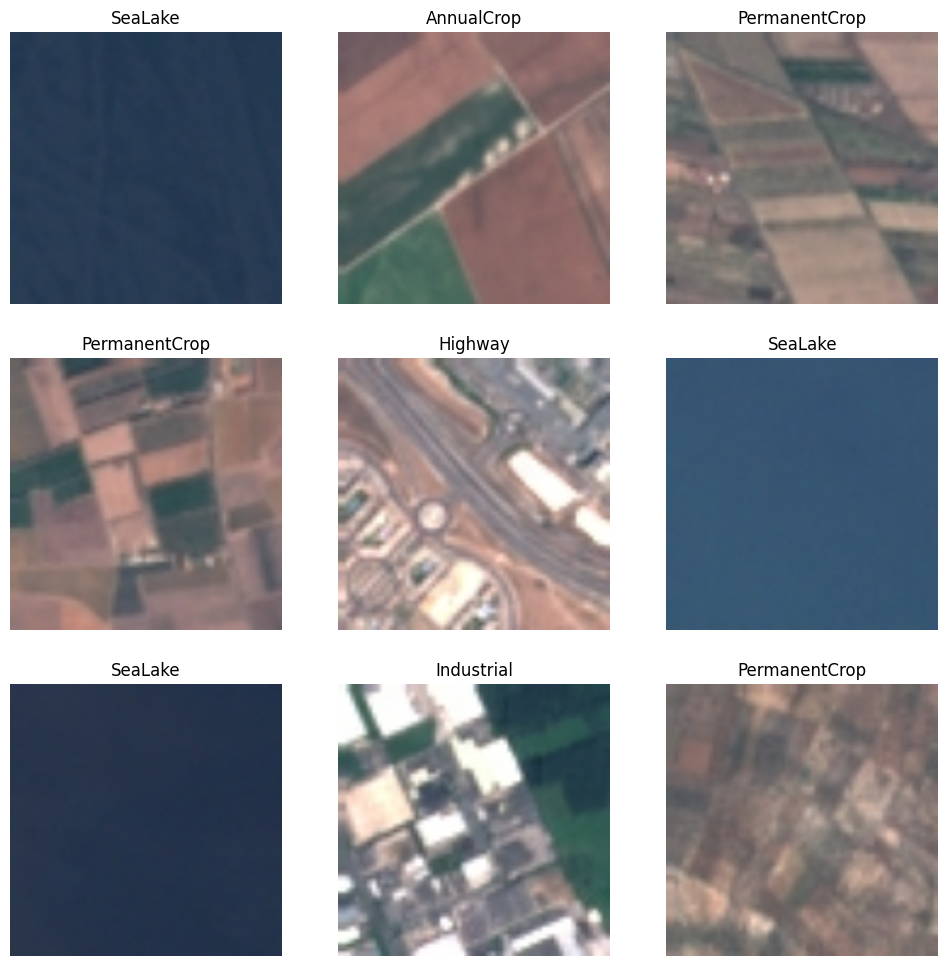

In [5]:
plt.figure(figsize=(12, 12))

for images, labels in train_ds.take(1):

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [6]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2)
])

print("Data Augmentation Ready")

Data Augmentation Ready


In [7]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

print("EfficientNetB0 Loaded")

EfficientNetB0 Loaded


In [8]:
from tensorflow.keras import Sequential
from tensorflow.keras import layers
from tensorflow.keras import Input
from tensorflow.keras.applications.efficientnet import preprocess_input

model = Sequential([
    Input(shape=(224, 224, 3)),

    data_augmentation,

    layers.Lambda(preprocess_input),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.BatchNormalization(),

    layers.Dropout(0.4),

    layers.Dense(
        256,
        activation="relu"
    ),

    layers.Dropout(0.3),

    layers.Dense(
        len(class_names),
        activation="softmax"
    )
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385,197 (16.73 MB)

 Trainable params: 333,066 (1.27 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [10]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model Compiled Successfully")

Model Compiled Successfully


In [11]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_geoscope_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

print("Callbacks Ready")

Callbacks Ready


In [12]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=[
        early_stop,
        checkpoint
    ]
)

Epoch 1/8
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 737s 530ms/step - accuracy: 0.6028 - loss: 1.2798 - val_accuracy: 0.9192 - val_loss: 0.2506
Epoch 2/8
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 748s 553ms/step - accuracy: 0.8383 - loss: 0.5016 - val_accuracy: 0.9342 - val_loss: 0.2103
Epoch 3/8
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 705s 520ms/step - accuracy: 0.8641 - loss: 0.4194 - val_accuracy: 0.9411 - val_loss: 0.1858
Epoch 4/8
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 693s 512ms/step - accuracy: 0.8766 - loss: 0.3740 - val_accuracy: 0.9433 - val_loss: 0.1779
Epoch 5/8
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 680s 502ms/step - accuracy: 0.8821 - loss: 0.3549 - val_accuracy: 0.9426 - val_loss: 0.1734
Epoch 6/8
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 690s 510ms/step - accuracy: 0.8884 - loss: 0.3384 - val_accuracy: 0.9466 - val_loss: 0.1617
Epoch 7/8
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 705s 521ms/step - accuracy: 0.8946 - loss: 0.3247 - val_accuracy: 0.9448 - val_loss: 0.1690
Epoch 8/8
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 702s 518ms/step - accuracy: 

In [13]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [16]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    initial_epoch=8,
    callbacks=[early_stop, checkpoint]
)

Epoch 9/15
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 979s 685ms/step - accuracy: 0.7560 - loss: 0.7525 - val_accuracy: 0.9307 - val_loss: 0.2143
Epoch 10/15
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 841s 621ms/step - accuracy: 0.8438 - loss: 0.4773 - val_accuracy: 0.9401 - val_loss: 0.1884
Epoch 11/15
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 822s 608ms/step - accuracy: 0.8581 - loss: 0.4319 - val_accuracy: 0.9444 - val_loss: 0.1754
Epoch 12/15
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 848s 626ms/step - accuracy: 0.8694 - loss: 0.3887 - val_accuracy: 0.9489 - val_loss: 0.1628
Epoch 13/15
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 830s 613ms/step - accuracy: 0.8796 - loss: 0.3650 - val_accuracy: 0.9496 - val_loss: 0.1579
Epoch 14/15
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 809s 598ms/step - accuracy: 0.8853 - loss: 0.3596 - val_accuracy: 0.9529 - val_loss: 0.1522
Epoch 15/15
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 851s 629ms/step - accuracy: 0.8930 - loss: 0.3236 - val_accuracy: 0.9557 - val_loss: 0.1468


In [20]:
model.save("geoscope_model.keras")

print("Model Saved Successfully")

Model Saved Successfully


In [75]:
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input

model = load_model(
    "geoscope_model.keras",
    custom_objects={"preprocess_input": preprocess_input}
)

In [76]:
import tensorflow as tf
import numpy as np

img_path = r"C:\Users\HP\Downloads\GeoScope-AI\test\Landcover.jpg"
img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
pred = model.predict(img_array)
pred_class = np.argmax(pred)

print("Prediction Index:", pred_class)
print("Prediction Confidence:", np.max(pred))
print("Predicted Class:", class_names[pred_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Prediction Index: 5
Prediction Confidence: 0.6145099
Predicted Class: Pasture


1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


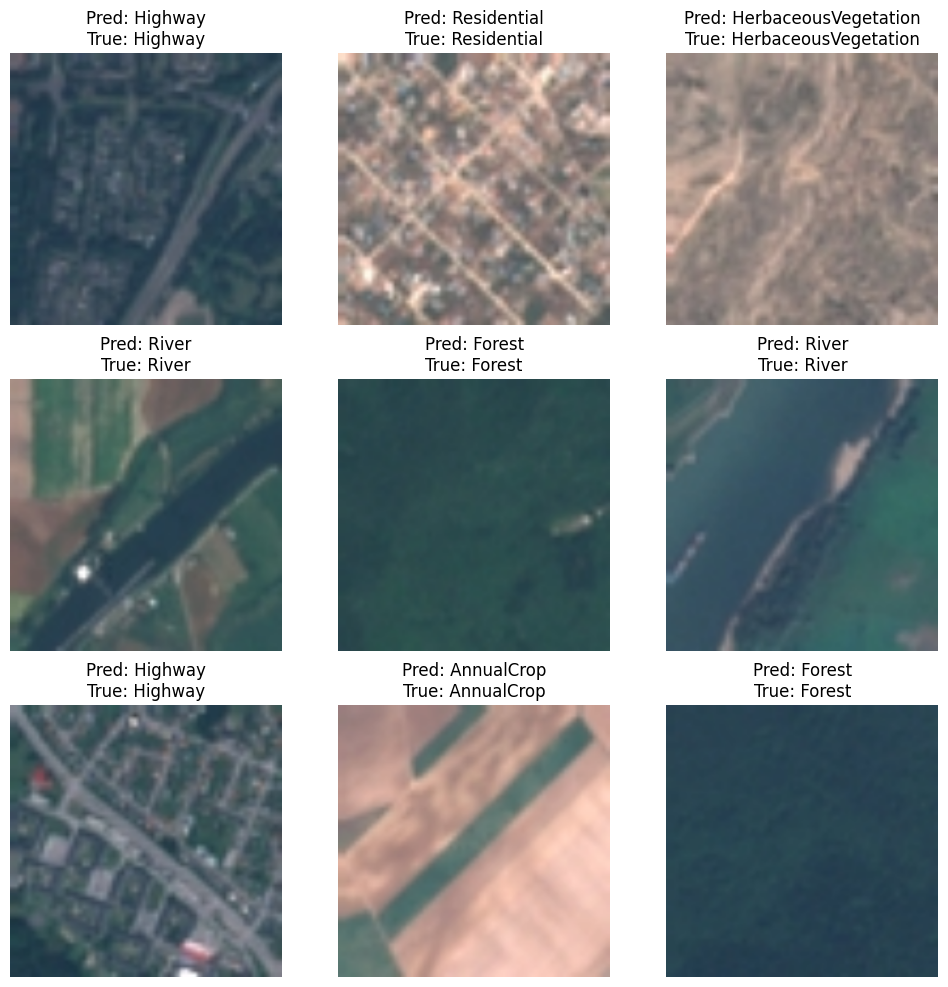

In [28]:
import matplotlib.pyplot as plt
import numpy as np

for images, labels in val_ds.take(1):

    preds = model.predict(images)

    plt.figure(figsize=(12, 12))

    for i in range(9):
        ax = plt.subplot(3, 3, i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        pred_class = np.argmax(preds[i])
        true_class = labels[i].numpy()

        plt.title(f"Pred: {class_names[pred_class]}\nTrue: {class_names[true_class]}")
        plt.axis("off")

    plt.show()

In [29]:
for images, labels in train_ds.take(1):
    preds = model.predict(images)

    for i in range(5):
        print("True:", class_names[labels[i]])
        print("Pred:", class_names[np.argmax(preds[i])])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 625ms/step
True: HerbaceousVegetation
Pred: HerbaceousVegetation
True: HerbaceousVegetation
Pred: HerbaceousVegetation
True: Residential
Pred: Residential
True: SeaLake
Pred: SeaLake
True: Highway
Pred: Residential


In [30]:
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 603ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 554ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 587ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 503ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 535ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 607ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 524ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 512ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 534ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 557ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 590ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 524ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 531ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 524ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 582ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [31]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

                      precision    recall  f1-score   support

          AnnualCrop       0.95      0.94      0.95       594
              Forest       0.95      0.99      0.97       597
HerbaceousVegetation       0.94      0.95      0.95       560
             Highway       0.94      0.94      0.94       492
          Industrial       0.96      0.98      0.97       511
             Pasture       0.94      0.91      0.93       374
       PermanentCrop       0.93      0.92      0.93       494
         Residential       0.98      0.98      0.98       603
               River       0.96      0.95      0.95       550
             SeaLake       1.00      0.97      0.98       621

            accuracy                           0.96      5396
           macro avg       0.95      0.95      0.95      5396
        weighted avg       0.96      0.96      0.96      5396



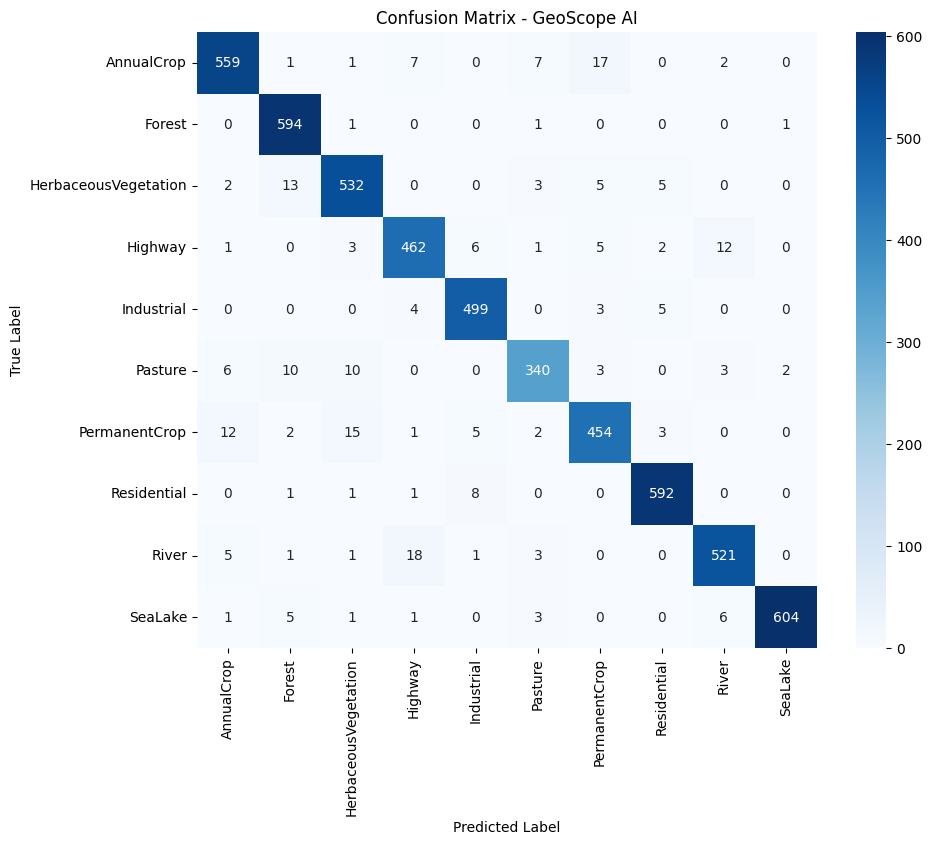

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - GeoScope AI")
plt.show()

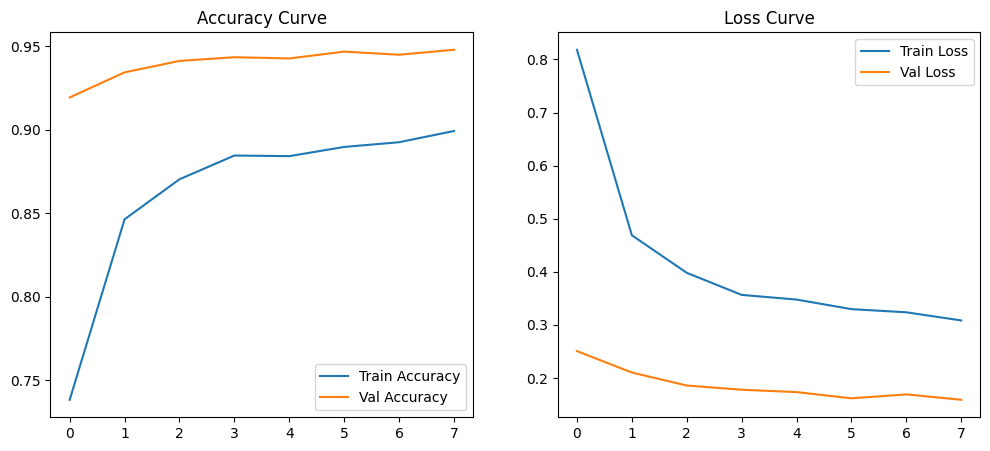

In [33]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy Curve")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Curve")
plt.legend()

plt.show()

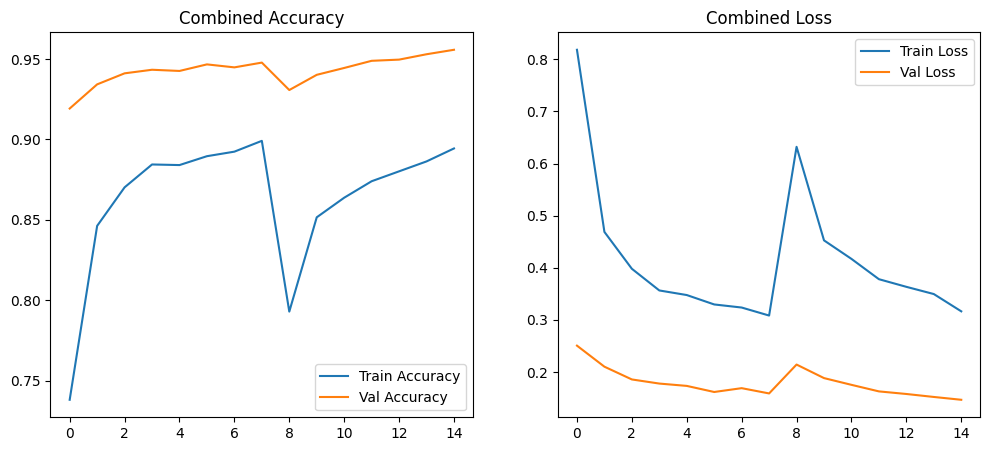

In [34]:
import matplotlib.pyplot as plt

acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']

loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Val Accuracy')
plt.title("Combined Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Val Loss')
plt.title("Combined Loss")
plt.legend()

plt.show()

In [35]:
from sklearn.metrics import accuracy_score

for i, class_name in enumerate(class_names):
    idx = (y_true == i)
    acc = accuracy_score(y_true[idx], y_pred[idx])
    print(f"{class_name}: {acc:.2f}")

AnnualCrop: 0.94
Forest: 0.99
HerbaceousVegetation: 0.95
Highway: 0.94
Industrial: 0.98
Pasture: 0.91
PermanentCrop: 0.92
Residential: 0.98
River: 0.95
SeaLake: 0.97


In [67]:
for layer in model.layers:
    print(layer.name)

sequential
lambda
efficientnetb0
global_average_pooling2d
batch_normalization
dropout
dense
dropout_1
dense_1


In [68]:
base_model = model.get_layer("efficientnetb0")

for layer in reversed(base_model.layers):
    print(layer.name)
    break

top_activation


In [69]:
base_model = model.get_layer("efficientnetb0")

for layer in reversed(base_model.layers):
    try:
        if len(layer.output.shape) == 4:
            print("Last Conv Candidate:", layer.name)
            break
    except:
        pass

Last Conv Candidate: top_activation


In [70]:
base_model = model.get_layer("efficientnetb0")

last_conv_layer = base_model.get_layer("top_conv")

print(last_conv_layer)

<Conv2D name=top_conv, built=True>


In [77]:
print(model.name)
print(type(model))
print(model.built)

sequential_1
<class 'keras.src.models.sequential.Sequential'>
True


In [78]:
print("Inputs:", model.inputs)
print("Outputs:", model.outputs)

Inputs: [<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=input_layer_1>]
Outputs: [<KerasTensor shape=(None, 10), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1392>]


In [79]:
base_model = model.get_layer("efficientnetb0")

print("Base model name:", base_model.name)
print("Base model input:", base_model.input)
print("Base model output:", base_model.output)

Base model name: efficientnetb0
Base model input: [<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=input_layer>]
Base model output: <KerasTensor shape=(None, 7, 7, 1280), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1336>


In [80]:
base_model = model.get_layer("efficientnetb0")

target_layer = base_model.get_layer("top_conv")

print(target_layer.name)
print(target_layer.output)

top_conv
<KerasTensor shape=(None, 7, 7, 1280), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1332>


In [135]:
img = tf.keras.utils.load_img(
    r"C:\Users\HP\Downloads\GeoScope-AI\dataset\EuroSAT_RGB\River\River_502.jpg",
    target_size=(224,224)
)

img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

In [136]:
preds = model.predict(img_array)

print(preds[0])

print("Predicted Class:", class_names[np.argmax(preds)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
[1.3337842e-04 4.8568950e-08 1.9487770e-06 1.3322206e-03 5.3070607e-07
 1.3154596e-06 4.8675582e-05 4.9381774e-06 9.9847442e-01 2.5853863e-06]
Predicted Class: River


In [137]:
top3 = np.argsort(preds[0])[-3:][::-1]

for idx in top3:
    print(
        class_names[idx],
        f"{preds[0][idx]*100:.2f}%"
    )

River 99.85%
Highway 0.13%
AnnualCrop 0.01%


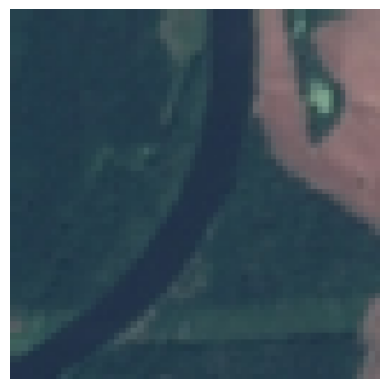

In [138]:
plt.imshow(img)
plt.axis("off")
plt.show()

In [156]:
for images, labels in val_ds.take(1):

    preds = model.predict(images)

    for i in range(5):

        pred = np.argmax(preds[i])

        print(
            "True:",
            class_names[labels[i]],
            "| Pred:",
            class_names[pred]
        )

    break

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step
True: Highway | Pred: Highway
True: River | Pred: River
True: Pasture | Pred: Pasture
True: SeaLake | Pred: SeaLake
True: AnnualCrop | Pred: AnnualCrop


In [119]:
preds = model.predict(img_array)

for i in np.argsort(preds[0])[::-1][:5]:
    print(
        class_names[i],
        f"{preds[0][i]*100:.2f}%"
    )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
PermanentCrop 56.95%
Residential 24.69%
HerbaceousVegetation 14.79%
Industrial 1.87%
Forest 0.64%


In [170]:
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input

model = load_model(
    "geoscope_fixed.keras",
    custom_objects={
        "preprocess_input": preprocess_input
    },
    compile=False
)

In [169]:
import tensorflow as tf
print(tf.__version__)
print(tf.keras.__version__)

2.19.0
3.10.0


In [171]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385,197 (16.73 MB)

 Trainable params: 1,829,226 (6.98 MB)

 Non-trainable params: 2,555,971 (9.75 MB)

In [172]:
print(type(base_model))
print(base_model.input)
print(base_model.output)

<class 'keras.src.models.functional.Functional'>
[<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=input_layer>]
<KerasTensor shape=(None, 7, 7, 1280), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1902>


In [175]:
from tensorflow.keras.applications.efficientnet import preprocess_input

model = tf.keras.models.load_model(
    "geoscope_fixed.keras",
    compile=False,
    custom_objects={
        "preprocess_input": preprocess_input
    }
)

print("MODEL LOADED SUCCESSFULLY")

MODEL LOADED SUCCESSFULLY
